# Accessible PlantUML Class Diagrams

This notebook demonstrates how to create an accessibility-aware class diagram in PlantUML from Python.

## What this diagram is used for

Class diagrams represent object-oriented structures such as classes, attributes, methods, inheritance, and associations.

## How to make it more accessible

Use descriptive class names, expose important attributes and methods explicitly, organize relationships clearly, avoid excessive inheritance depth, and accompany the diagram with a textual explanation of the relationships.

## Setup

These notebooks use **Python to write PlantUML source code and call PlantUML locally** to render the diagram.

PlantUML must therefore be available on your system. A local PlantUML installation requires Java, and some diagram types may also require Graphviz.

You can use PlantUML in either of these ways:

1. **Install the PlantUML command-line tool** using the package manager available on your operating system.
2. **Download `plantuml.jar`** from the PlantUML website and run it with Java.

After installation, verify that PlantUML is available by running:

```bash
plantuml -version
```

If you use a downloaded `plantuml.jar` instead of a `plantuml` command, set the `PLANTUML_JAR` environment variable to the path of the JAR file before running the notebook.

The Python helper below supports both approaches.

In [1]:
from pathlib import Path
import os
import shutil
import subprocess

from IPython.display import Image, display


def render_plantuml(source, filename):
    """Save PlantUML source, render it as PNG, and display it."""
    source_path = Path(f"{filename}.puml")
    source_path.write_text(source, encoding="utf-8")

    plantuml_executable = shutil.which("plantuml")
    plantuml_jar = os.environ.get("PLANTUML_JAR")

    if plantuml_executable:
        command = [
            plantuml_executable,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    elif plantuml_jar:
        command = [
            "java",
            "-jar",
            plantuml_jar,
            "-charset", "UTF-8",
            "-tpng",
            str(source_path),
        ]
    else:
        raise RuntimeError(
            "PlantUML was not found. Install the 'plantuml' command "
            "or set PLANTUML_JAR to the path of plantuml.jar."
        )

    result = subprocess.run(command, capture_output=True, text=True)

    if result.returncode != 0:
        raise RuntimeError("PlantUML rendering failed:\n" + result.stderr)

    image_path = source_path.with_suffix(".png")
    if not image_path.exists():
        raise FileNotFoundError(f"Rendered image was not created: {image_path}")

    display(Image(filename=str(image_path)))
    return image_path


## Accessible example

The example below creates an accessibility-aware class diagram also presented in the Guidelines document.

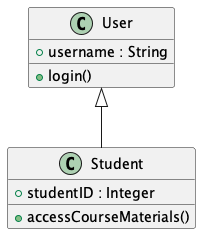

PosixPath('accessible_class_diagram.png')

In [ ]:
class_source = """@startuml
skinparam dpi 300
class User {
  +username : String
  +login()
}

class Student {
  +studentID : Integer
  +accessCourseMaterials()
}

User <|-- Student
@enduml
"""

render_plantuml(class_source, "accessible_class_diagram")

## Accessible description

Class diagram containing User and Student. User defines a `username` attribute of type String and a `login()` method. Student defines a `studentID` attribute of type Integer and an `accessCourseMaterials()` method. Student inherits from User, so Student extends the properties and behaviors defined by User.

## Reusable accessible template

Replace the class names, members, and relationship with meaningful concepts from your own object-oriented model.

In [ ]:
class_template = """@startuml
class ParentClass {
  +meaningfulAttribute : Type
  +meaningfulMethod()
}

class ChildClass {
  +specificAttribute : Type
  +specificMethod()
}

ParentClass <|-- ChildClass
@enduml
"""

render_plantuml(class_template, "class_diagram_template")

## Accessible description template

After replacing the placeholder source with your own class diagram, add a concise textual description that:

- identifies the diagram type and purpose,
- names the important entities, classes, actions, states, or nodes,
- explains the relationships or interaction order,
- describes decision or transition logic where relevant,
- and states the key structural takeaway.

Do not rely on spatial wording alone. The description should communicate the important relationships encoded by the diagram.
